# Algoritmo Genético N Queens

In [179]:
%pip install numpy matplotlib

import random
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [180]:
m = 50
n = 8
geracoes = 50
taxa_mutacao = 0.05

In [181]:
def imprime_matriz(matriz):
    for i in range(matriz.shape[0]):
        if i < 9:
            print(f' {[i+1]} ', end='')
        else:
            print(f'{[i+1]} ', end='')
        for j in range(matriz.shape[1]):
            print(matriz[i][j], end=' ')
        print()

def imprime_conflitos(conflitos):
    for i in range(conflitos.shape[0]):
        if i < 9:
            print(f' {[i+1]} ', end='')
        else:
            print(f'{[i+1]} ', end='')
        print(conflitos[i][0])

def gerar_populacao(m, n):
    matriz = np.zeros((m, n), dtype=int)
    for i in range(m):
        for j in range(n):
            matriz[i][j] = random.randint(1, n)
    return matriz


def verifica_conflitos(matriz):

    conflitos = np.zeros((matriz.shape[0], 1), dtype=int)

    # verifica conflitos para cada indivíduo
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            for k in range(j + 1, matriz.shape[1]):

                # conflito na mesma coluna
                if matriz[i][k] == matriz[i][j]:
                    conflitos[i] += 1

                # conflito na diagonal
                if abs(j - k) == abs(matriz[i][j] - matriz[i][k]):
                    conflitos[i] += 1

    return conflitos, conflitos.sum()


def seleciona_pai_binario(conflitos):
    
    # seleciona dois indivíduos aleatórios
    pai_01_index = random.randint(0, len(conflitos) - 1)
    pai_02_index = random.randint(0, len(conflitos) - 1)

    # garante que os dois indivíduos selecionados sejam diferentes
    while pai_02_index == pai_01_index:
        pai_02_index = random.randint(0, len(conflitos) - 1)

    if conflitos[pai_01_index][0] < conflitos[pai_02_index][0]:
        return pai_01_index
    else:
        return pai_02_index


def cruzamento(pai_01, pai_02, ponto_corte):

    # gera dois filhos a partir de dois pais e um ponto de corte
    filho_01 = np.concatenate((pai_01[:ponto_corte], pai_02[ponto_corte:]))
    filho_02 = np.concatenate((pai_02[:ponto_corte], pai_01[ponto_corte:]))

    return filho_01, filho_02


def mutacao(filho, taxa, n):
    
    # mutação simples que altera um gene aleatório do filho com uma nova posição aleatória
    if random.random() < taxa:
        posicao = random.randint(0, len(filho) - 1)
        novo_valor = random.randint(1, n)

        while novo_valor == filho[posicao]:
            novo_valor = random.randint(1, n)

        filho[posicao] = novo_valor

    return filho

In [182]:
matriz_ind_inicial = gerar_populacao(m, n)

print("POPULAÇÃO INICIAL:\n")
imprime_matriz(matriz_ind_inicial)

conflitos, qtdd_conflitos_inicial = verifica_conflitos(matriz_ind_inicial)

print(f"\nQuantidade total de conflitos inicial: {qtdd_conflitos_inicial}")
print("\nConflitos por indivíduo:")
imprime_conflitos(conflitos)

POPULAÇÃO INICIAL:

 [1] 1 2 8 8 4 5 8 6 
 [2] 2 3 5 5 1 5 7 1 
 [3] 1 1 3 3 6 3 4 5 
 [4] 6 7 7 6 7 3 1 6 
 [5] 6 5 4 6 6 5 1 3 
 [6] 1 2 6 1 7 2 3 4 
 [7] 4 1 8 6 3 7 4 4 
 [8] 2 7 2 8 3 7 6 4 
 [9] 5 2 4 2 8 6 5 8 
[10] 4 3 4 5 8 4 6 3 
[11] 8 8 4 6 1 8 3 2 
[12] 3 5 2 3 8 7 1 4 
[13] 7 5 1 8 1 4 8 8 
[14] 5 8 5 7 2 2 3 8 
[15] 8 1 4 3 3 6 5 1 
[16] 8 6 6 6 6 6 8 4 
[17] 8 8 1 6 1 3 4 1 
[18] 8 6 5 8 4 5 1 5 
[19] 5 5 8 7 1 4 2 4 
[20] 5 3 5 2 7 5 7 5 
[21] 6 1 7 6 8 5 2 1 
[22] 7 8 2 5 8 4 1 6 
[23] 6 2 8 8 1 7 5 7 
[24] 5 7 3 3 2 5 5 6 
[25] 4 6 5 8 6 7 8 1 
[26] 7 5 6 7 2 2 5 8 
[27] 7 7 6 4 1 8 5 8 
[28] 4 2 3 1 1 1 7 3 
[29] 5 8 6 4 8 5 5 7 
[30] 4 7 2 3 7 1 2 7 
[31] 4 2 3 7 3 5 3 4 
[32] 1 8 7 6 4 3 4 7 
[33] 6 5 2 2 6 1 2 2 
[34] 1 3 8 1 2 3 5 4 
[35] 7 2 6 1 7 1 5 2 
[36] 2 6 8 7 7 7 8 8 
[37] 7 1 6 3 2 3 3 3 
[38] 4 8 1 2 1 6 7 8 
[39] 1 3 1 3 1 6 4 2 
[40] 4 2 4 3 8 2 1 8 
[41] 7 7 7 6 8 1 2 3 
[42] 6 6 3 3 1 4 6 7 
[43] 6 4 3 2 6 3 2 5 
[44] 6 7 4 3 8 6 7 2 
[45] 6 3 7 4


Geração 1
Conflitos totais: 394
Conflitos médios por indivíduo: 7.88

Geração 2
Conflitos totais: 354
Conflitos médios por indivíduo: 7.08

Geração 3
Conflitos totais: 322
Conflitos médios por indivíduo: 6.44

Geração 4
Conflitos totais: 282
Conflitos médios por indivíduo: 5.64

Geração 5
Conflitos totais: 252
Conflitos médios por indivíduo: 5.04

Geração 6
Conflitos totais: 242
Conflitos médios por indivíduo: 4.84

Geração 7
Conflitos totais: 243
Conflitos médios por indivíduo: 4.86

Geração 8
Conflitos totais: 197
Conflitos médios por indivíduo: 3.94

Geração 9
Conflitos totais: 186
Conflitos médios por indivíduo: 3.72

Geração 10
Conflitos totais: 154
Conflitos médios por indivíduo: 3.08

Geração 11
Conflitos totais: 135
Conflitos médios por indivíduo: 2.70

Geração 12
Conflitos totais: 110
Conflitos médios por indivíduo: 2.20

Geração 13
Conflitos totais: 89
Conflitos médios por indivíduo: 1.78

Geração 14
Conflitos totais: 70
Conflitos médios por indivíduo: 1.40

Geração 15
Confl

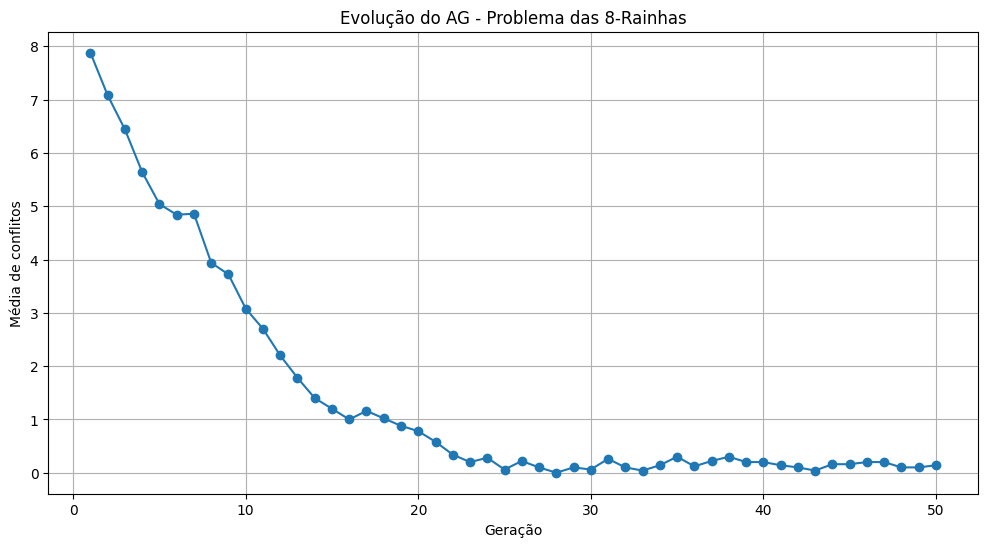

In [183]:
matriz_atual = matriz_ind_inicial.copy()
historico_conflitos = []

for geracao in range(geracoes):

    # calcula conflitos da população atual
    conflitos, conflitos_total = verifica_conflitos(matriz_atual)
    media_conflitos = conflitos_total / m
    historico_conflitos.append(media_conflitos)

    print(f"\n==============================================")
    print(f"Geração {geracao + 1}")
    print(f"Conflitos totais: {conflitos_total}")
    print(f"Conflitos médios por indivíduo: {media_conflitos:.2f}")
    print(f"==============================================")

    # nova geração
    nova_populacao = np.zeros_like(matriz_atual)

    indice = 0
    while indice < m:

        # seleção de pais
        pai_01_index = seleciona_pai_binario(conflitos)
        pai_02_index = seleciona_pai_binario(conflitos)

        pai_01 = matriz_atual[pai_01_index]
        pai_02 = matriz_atual[pai_02_index]

        # cruzamento
        ponto_corte = random.randint(1, n - 1)
        filho_01, filho_02 = cruzamento(pai_01, pai_02, ponto_corte)

        # mutação
        filho_01 = mutacao(filho_01, taxa_mutacao, n)
        filho_02 = mutacao(filho_02, taxa_mutacao, n)

        # inserir filhos na nova população
        nova_populacao[indice] = filho_01
        if indice + 1 < m:
            nova_populacao[indice + 1] = filho_02

        indice += 2

    # substitui população atual pela nova geração
    matriz_atual = nova_populacao.copy()

# avaliação final
conflitos_finais, qtdd_conflitos_final = verifica_conflitos(matriz_atual)

print("\n\n===== RESUMO FINAL =====")
print(f"Conflitos iniciais: {qtdd_conflitos_inicial}")
print(f"Conflitos finais:   {qtdd_conflitos_final}")

reducao = qtdd_conflitos_inicial - qtdd_conflitos_final
percentual = (reducao / qtdd_conflitos_inicial) * 100 if qtdd_conflitos_inicial > 0 else 0

print(f"Redução: {reducao} conflitos ({percentual:.1f}%)")

print("\nConflitos por indivíduo na população final:")
imprime_conflitos(conflitos_finais)

print("\nPopulação final:")
imprime_matriz(matriz_atual)

# GRÁFICO
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(historico_conflitos) + 1), historico_conflitos, marker='o')
plt.xlabel('Geração')
plt.ylabel('Média de conflitos')
plt.title(f'Evolução do AG - Problema das {n}-Rainhas')
plt.grid(True)
plt.show()